# Fixed DQN + Stable Baselines3 for EV2Gym 🚗⚡

This notebook includes:
1. **Fixed DQN** - Addresses Q-value explosion, loss increase, convergence issues
2. **Stable Baselines3** - Production-ready TD3, SAC, DDPG with continuous actions
3. **Comprehensive comparison** - Compare all methods with baselines

## Issues Fixed from Previous Version:
- ❌ Q-value explosion (0 → 200)
- ❌ Loss increasing instead of decreasing
- ❌ No convergence in tracking error
- ❌ Action space limitation (all ports same value)

## Solutions Applied:
- ✅ Q-value clipping
- ✅ Double DQN to prevent overestimation
- ✅ Lower learning rate (1e-5)
- ✅ Simpler reward function
- ✅ Continuous actions with TD3/SAC (Stable Baselines3)

## Part 1: Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import namedtuple, deque
from itertools import count
import random
import math
import pickle
import json

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Change to project root directory (needed for EV2Gym data paths)
# If running in Jupyter, this will be the tutorials/ directory
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")

from ev2gym.models.ev2gym_env import EV2Gym

# Import Stable Baselines3 and Gym
import gymnasium as gym
from stable_baselines3 import TD3, SAC, DDPG, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.noise import NormalActionNoise

# Import reward and state functions from ev2gym
from ev2gym.rl_agent.reward import SquaredTrackingErrorReward
from ev2gym.rl_agent.state import PublicPST

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Working directory: /Users/josepedroevans/Desktop/MECD/TASI/EV2Gym


/Users/josepedroevans/Desktop/MECD/TASI/EV2Gym/ev2gym/utilities/loaders.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using device: cpu


## Part 2: Choose Your Approach

**Recommendation**: Start with Stable Baselines3 (Skip to Part 4) for best results.

- **Part 3**: Fixed DQN (discrete actions, all ports controlled identically)
- **Part 4**: Stable Baselines3 TD3/SAC (continuous actions, independent port control) ⭐ **Recommended**

---
# Part 3: Fixed DQN Implementation

This section contains the fixed DQN with all stability improvements.

### 3.1: Fixed DQN Configuration

In [3]:
# ============================================================================
# FIXED DQN CONFIGURATION
# ============================================================================

DQN_CONFIG = {
    "num_episodes": 3000,
    "batch_size": 32,        # Smaller for stability
    "lr": 1e-5,              # MUCH lower than before (was 5e-5)
    "gamma": 0.90,           # Lower discount factor
    "eps_start": 1.0,
    "eps_end": 0.05,
    "eps_decay": 10000,      # Slower decay
    "tau": 0.001,            # Slower target updates (was 0.005)
    "memory_size": 50000,
    "n_actions": 11,
    "hidden_size": 64,       # Smaller network (was 128)
    "use_double_dqn": True,  # NEW: Double DQN
    "clip_q_values": False,   # NEW: Q-value clipping
    "q_clip_min": -10,
    "q_clip_max": 10,
    "gradient_clip": 1.0,    # Lower gradient clipping (was 10.0)
    "print_freq": 10,
    "save_freq": 50,
}

print("Fixed DQN Configuration:")
print("=" * 70)
for key, value in DQN_CONFIG.items():
    print(f"  {key:20s}: {value}")
print("=" * 70)

Fixed DQN Configuration:
  num_episodes        : 3000
  batch_size          : 32
  lr                  : 1e-05
  gamma               : 0.9
  eps_start           : 1.0
  eps_end             : 0.05
  eps_decay           : 10000
  tau                 : 0.001
  memory_size         : 50000
  n_actions           : 11
  hidden_size         : 64
  use_double_dqn      : True
  clip_q_values       : False
  q_clip_min          : -10
  q_clip_max          : 10
  gradient_clip       : 1.0
  print_freq          : 10
  save_freq           : 50


### 3.2: Environment Setup for DQN

In [24]:
# Setup paths
config_file = "ev2gym/example_config_files/PublicPST.yaml"

# Create environment
dqn_env = EV2Gym(
    config_file=config_file,
    render_mode=False,
    seed=42,
    save_plots=False,
    save_replay=False,
    verbose=False
)

# Get environment info
state, _ = dqn_env.reset()
n_observations = len(state)
total_ports = sum(cs.n_ports for cs in dqn_env.charging_stations)

print(f"State dimension: {n_observations}")
print(f"Total ports: {total_ports}")
print(f"Simulation length: {dqn_env.simulation_length} steps")
print(f"Number of charging stations: {len(dqn_env.charging_stations)}")

# Action discretization
def discretize_action(action_idx, n_actions=DQN_CONFIG['n_actions']):
    value = action_idx / (n_actions - 1)
    return [value] * total_ports

print(f"\nAction discretization: {DQN_CONFIG['n_actions']} discrete levels")

State dimension: 63
Total ports: 20
Simulation length: 112 steps
Number of charging stations: 20

Action discretization: 11 discrete levels


### 3.3: Simple Reward Function

In [25]:
def reward_normalized_simple(env, *args):
    """
    Normalized tracking reward - SIMPLE and STABLE.
    This is the same as Helena's v2 but without the multi-objective complexity.
    """
    error = min(env.power_setpoints[env.current_step-1],
                env.charge_power_potential[env.current_step-1]) - \
            env.current_power_usage[env.current_step-1]
    squared_error = error ** 2

    max_possible = max(abs(env.power_setpoints[env.current_step-1]),
                       abs(env.charge_power_potential[env.current_step-1]))
    max_squared_error = max_possible ** 2 if max_possible > 0 else 1

    reward = -squared_error / max_squared_error

    # Small bonus for excellent tracking
    if abs(error) < 0.05 * max_possible:
        reward += 0.1

    return max(-1, min(reward, 0.1))

# Set reward function
dqn_env.set_reward_function(reward_normalized_simple)
print("Using simplified normalized reward function")

Using simplified normalized reward function


### 3.4: Simple DQN with Batch Normalization

In [26]:
class SimpleDQN(nn.Module):
    """Simple DQN with batch normalization."""
    def __init__(self, n_observations, n_actions, hidden_size=64):
        super(SimpleDQN, self).__init__()
        
        self.fc1 = nn.Linear(n_observations, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_actions)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

# Initialize networks
policy_net = SimpleDQN(n_observations, DQN_CONFIG['n_actions'], DQN_CONFIG['hidden_size']).to(device)
target_net = SimpleDQN(n_observations, DQN_CONFIG['n_actions'], DQN_CONFIG['hidden_size']).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

print("Network Architecture:")
print(policy_net)
print(f"\nTotal parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

Network Architecture:
SimpleDQN(
  (fc1): Linear(in_features=63, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=11, bias=True)
)

Total parameters: 9,227


### 3.5: Replay Memory and Training Components

In [27]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# Initialize
memory = ReplayMemory(DQN_CONFIG['memory_size'])
optimizer = optim.AdamW(policy_net.parameters(), lr=DQN_CONFIG['lr'], amsgrad=True)
steps_done = 0

print(f"Replay memory capacity: {DQN_CONFIG['memory_size']:,}")
print(f"Optimizer: AdamW with LR={DQN_CONFIG['lr']:.2e}")

Replay memory capacity: 50,000
Optimizer: AdamW with LR=1.00e-05


### 3.6: Fixed Training Functions with Double DQN and Q-Clipping

In [28]:
def get_epsilon(steps):
    return DQN_CONFIG['eps_end'] + (DQN_CONFIG['eps_start'] - DQN_CONFIG['eps_end']) * \
           math.exp(-1.0 * steps / DQN_CONFIG['eps_decay'])

def select_action(state):
    global steps_done
    eps_threshold = get_epsilon(steps_done)
    steps_done += 1
    
    if random.random() > eps_threshold:
        with torch.no_grad():
            policy_net.eval()
            action = policy_net(state).max(1).indices.view(1, 1)
            policy_net.train()
            return action
    else:
        return torch.tensor([[random.randrange(DQN_CONFIG['n_actions'])]], 
                          device=device, dtype=torch.long)

def optimize_model():
    """
    FIXED: Includes Double DQN and Q-value clipping.
    """
    if len(memory) < DQN_CONFIG['batch_size']:
        return None, None
    
    # Sample batch
    transitions = memory.sample(DQN_CONFIG['batch_size'])
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(
        tuple(map(lambda s: s is not None, batch.next_state)),
        device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    
    # Compute Q(s_t, a)
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    
    # **FIX 1: Clip Q-values to prevent explosion**
    if DQN_CONFIG['clip_q_values']:
        state_action_values = torch.clamp(
            state_action_values, 
            DQN_CONFIG['q_clip_min'], 
            DQN_CONFIG['q_clip_max']
        )
    
    # Compute V(s_{t+1})
    next_state_values = torch.zeros(DQN_CONFIG['batch_size'], device=device)
    
    if DQN_CONFIG['use_double_dqn']:
        # **FIX 2: Double DQN - prevents overestimation**
        with torch.no_grad():
            # Use policy network to SELECT best action
            best_actions = policy_net(non_final_next_states).max(1).indices.unsqueeze(1)
            # Use target network to EVALUATE that action
            next_state_values[non_final_mask] = target_net(non_final_next_states).gather(1, best_actions).squeeze()
    else:
        # Standard DQN
        with torch.no_grad():
            next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    
    # **FIX 3: Clip target Q-values too**
    if DQN_CONFIG['clip_q_values']:
        next_state_values = torch.clamp(
            next_state_values,
            DQN_CONFIG['q_clip_min'],
            DQN_CONFIG['q_clip_max']
        )
    
    # Compute expected Q values
    expected_state_action_values = (next_state_values * DQN_CONFIG['gamma']) + reward_batch
    
    # Compute loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    
    # Optimize
    optimizer.zero_grad()
    loss.backward()
    
    # **FIX 4: Stricter gradient clipping**
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), DQN_CONFIG['gradient_clip'])
    
    optimizer.step()
    
    # Return metrics for monitoring
    max_q = state_action_values.max().item()
    
    return loss.item(), max_q

def update_target_network():
    """Soft update of target network."""
    target_net_state = target_net.state_dict()
    policy_net_state = policy_net.state_dict()
    
    for key in policy_net_state:
        target_net_state[key] = (
            policy_net_state[key] * DQN_CONFIG['tau'] + 
            target_net_state[key] * (1 - DQN_CONFIG['tau'])
        )
    
    target_net.load_state_dict(target_net_state)

print("Training functions defined with fixes:")
print("  ✅ Double DQN")
print("  ✅ Q-value clipping")
print("  ✅ Gradient clipping")
print("  ✅ Lower learning rate")

Training functions defined with fixes:
  ✅ Double DQN
  ✅ Q-value clipping
  ✅ Gradient clipping
  ✅ Lower learning rate


### 3.7: Metrics Tracking

In [29]:
class MetricsTracker:
    def __init__(self):
        self.episode_rewards = []
        self.episode_stats = []
        self.losses = []
        self.q_values = []
        self.epsilons = []
        
    def log_step(self, loss, q_value, epsilon):
        if loss is not None:
            self.losses.append(loss)
        if q_value is not None:
            self.q_values.append(q_value)
        self.epsilons.append(epsilon)
    
    def log_episode(self, reward, stats):
        self.episode_rewards.append(reward)
        self.episode_stats.append(stats)
    
    def get_recent_avg(self, metric, window=10):
        data = getattr(self, metric)
        if len(data) == 0:
            return 0
        return np.mean(data[-window:])

metrics = MetricsTracker()
print("Metrics tracker initialized")

Metrics tracker initialized


### 3.8: Training Loop (Fixed DQN)

In [30]:
# Create run directory
RUN_NAME = f"fixed_dqn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = f"./runs/{RUN_NAME}"
os.makedirs(RUN_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"Starting FIXED DQN training: {DQN_CONFIG['num_episodes']} episodes")
print(f"Run directory: {RUN_DIR}")
print(f"{'='*70}\n")

# Training loop
for episode in range(DQN_CONFIG['num_episodes']):
    state, _ = dqn_env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    episode_reward = 0
    episode_losses = []
    episode_q_values = []
    
    for t in count():
        action = select_action(state)
        observation, reward, done, truncated, stats = dqn_env.step(
            discretize_action(action.item())
        )
        
        episode_reward += reward
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        
        if done:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        
        memory.push(state, action, next_state, reward_tensor)
        state = next_state
        
        # Optimize
        loss, max_q = optimize_model()
        if loss is not None:
            episode_losses.append(loss)
        if max_q is not None:
            episode_q_values.append(max_q)
        
        update_target_network()
        
        metrics.log_step(loss, max_q, get_epsilon(steps_done))
        
        if done:
            break
    
    metrics.log_episode(episode_reward, stats)
    
    # Print progress
    if (episode + 1) % DQN_CONFIG['print_freq'] == 0:
        avg_reward = metrics.get_recent_avg('episode_rewards', 10)
        avg_loss = np.mean(episode_losses) if episode_losses else 0
        avg_q = np.mean(episode_q_values) if episode_q_values else 0
        epsilon = get_epsilon(steps_done)
        tracking_error = stats.get('tracking_error', 0)
        
        print(f"Ep {episode+1:3d}/{DQN_CONFIG['num_episodes']} | "
              f"Rew: {episode_reward:6.2f} (avg: {avg_reward:6.2f}) | "
              f"Loss: {avg_loss:.4f} | "
              f"Q: {avg_q:5.2f} | "
              f"ε: {epsilon:.3f} | "
              f"TrackErr: {tracking_error:7.1f}")
        
        # **CONVERGENCE CHECK**
        if avg_loss > 1.0:
            print("  ⚠️  WARNING: Loss > 1.0, training may be unstable!")
        if avg_q > 10:
            print("  ⚠️  WARNING: Q-values > 10, possible divergence!")
    
    # Save checkpoint
    if (episode + 1) % DQN_CONFIG['save_freq'] == 0:
        checkpoint_path = f"{RUN_DIR}/checkpoint_ep{episode+1}.pth"
        torch.save({
            'episode': episode,
            'policy_net_state_dict': policy_net.state_dict(),
            'target_net_state_dict': target_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'steps_done': steps_done,
        }, checkpoint_path)

print(f"\n{'='*70}")
print("Fixed DQN training complete!")
print(f"{'='*70}")

# Save final model
torch.save(policy_net.state_dict(), f"{RUN_DIR}/final_model.pth")
with open(f"{RUN_DIR}/metrics.pkl", 'wb') as f:
    pickle.dump(metrics.__dict__, f)


Starting FIXED DQN training: 3000 episodes
Run directory: ./runs/fixed_dqn_20251128_105819

Ep  10/3000 | Rew: -10.36 (avg:  -8.62) | Loss: 0.0719 | Q:  0.92 | ε: 0.899 | TrackErr: 12603.9
Ep  20/3000 | Rew: -11.16 (avg:  -8.63) | Loss: 0.0658 | Q:  0.99 | ε: 0.809 | TrackErr:  4847.3
Ep  30/3000 | Rew:  -5.85 (avg:  -8.28) | Loss: 0.0596 | Q:  1.03 | ε: 0.729 | TrackErr: 11177.3
Ep  40/3000 | Rew:  -3.88 (avg:  -7.43) | Loss: 0.0575 | Q:  1.09 | ε: 0.657 | TrackErr: 13002.5
Ep  50/3000 | Rew:  -5.08 (avg:  -6.81) | Loss: 0.0538 | Q:  1.21 | ε: 0.593 | TrackErr: 12056.9
Ep  60/3000 | Rew:  -7.28 (avg:  -7.91) | Loss: 0.0507 | Q:  1.31 | ε: 0.535 | TrackErr: 18327.7
Ep  70/3000 | Rew: -13.23 (avg:  -9.86) | Loss: 0.0488 | Q:  1.41 | ε: 0.484 | TrackErr:  6690.6
Ep  80/3000 | Rew:  -7.21 (avg:  -6.76) | Loss: 0.0461 | Q:  1.41 | ε: 0.438 | TrackErr: 13607.5
Ep  90/3000 | Rew: -12.65 (avg:  -7.38) | Loss: 0.0476 | Q:  1.46 | ε: 0.397 | TrackErr: 19773.7
Ep 100/3000 | Rew: -10.12 (avg:  -

### 3.9: Analyze Fixed DQN Results

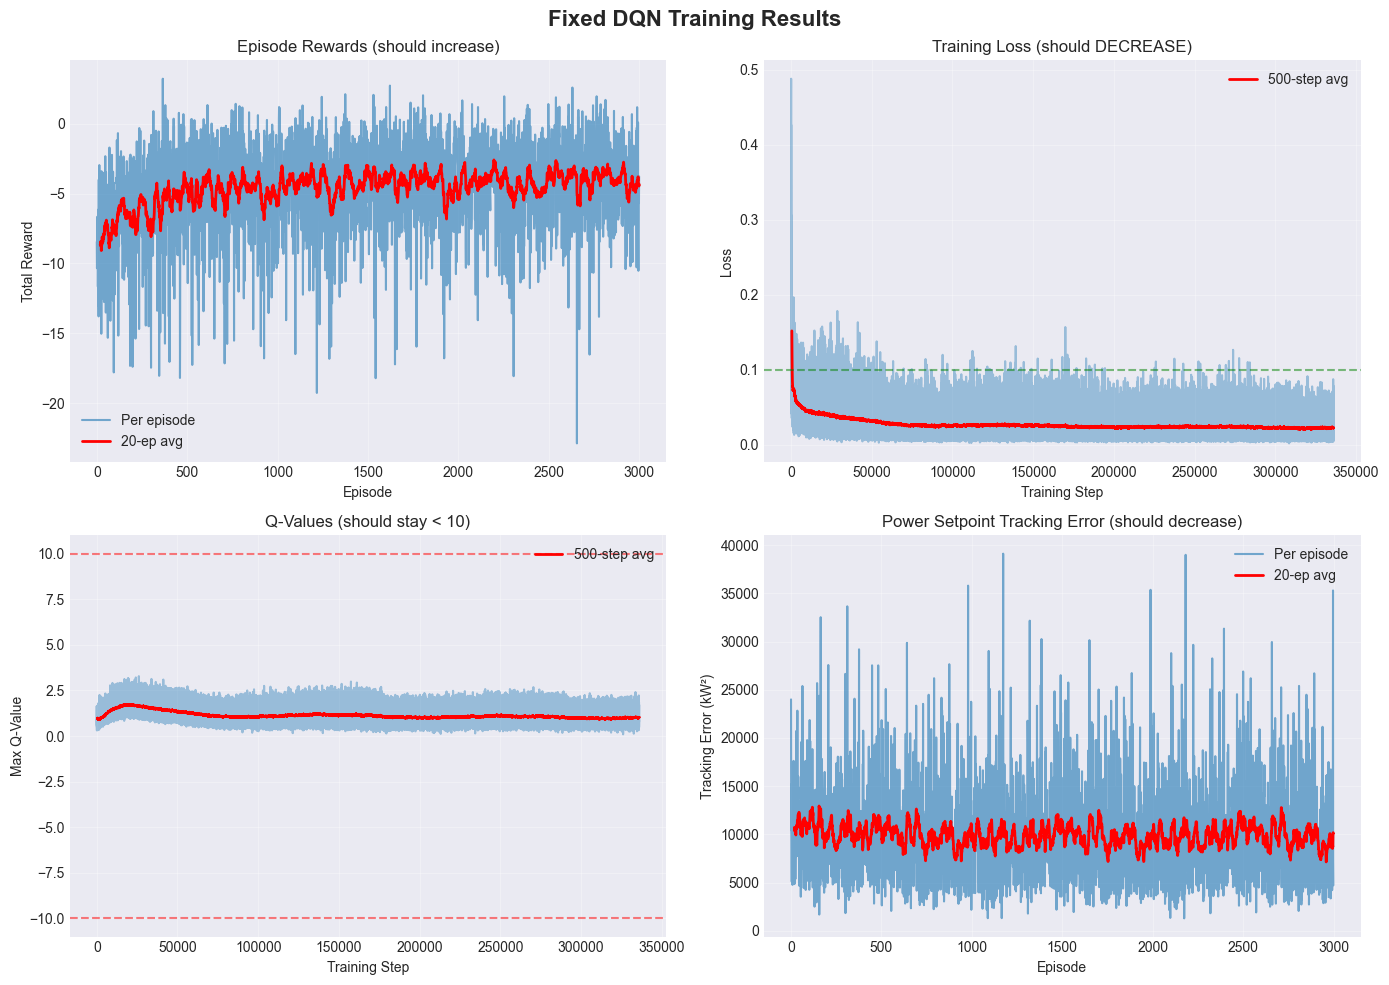


FIXED DQN SUMMARY
Final 10 episodes avg reward: -4.77
Final 10 episodes avg loss: 0.0237
Final 10 episodes avg Q-value: 1.01

Tracking error improvement: 4.4%
✅ SUCCESS: Model is learning!


In [31]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fixed DQN Training Results', fontsize=16, fontweight='bold')

# 1. Episode Rewards
ax = axes[0, 0]
ax.plot(metrics.episode_rewards, alpha=0.6, label='Per episode')
if len(metrics.episode_rewards) > 10:
    window = 20
    rolling_avg = pd.Series(metrics.episode_rewards).rolling(window=window).mean()
    ax.plot(rolling_avg, linewidth=2, label=f'{window}-ep avg', color='red')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Rewards (should increase)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Training Loss
ax = axes[0, 1]
if len(metrics.losses) > 0:
    ax.plot(metrics.losses, alpha=0.4)
    if len(metrics.losses) > 100:
        window = 500
        rolling_avg = pd.Series(metrics.losses).rolling(window=window).mean()
        ax.plot(rolling_avg, linewidth=2, label=f'{window}-step avg', color='red')
        ax.legend()
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (should DECREASE)')
ax.axhline(y=0.1, color='g', linestyle='--', alpha=0.5, label='Target ~0.1')
ax.grid(True, alpha=0.3)

# 3. Q-Values
ax = axes[1, 0]
if len(metrics.q_values) > 0:
    ax.plot(metrics.q_values, alpha=0.4)
    if len(metrics.q_values) > 100:
        window = 500
        rolling_avg = pd.Series(metrics.q_values).rolling(window=window).mean()
        ax.plot(rolling_avg, linewidth=2, label=f'{window}-step avg', color='red')
        ax.legend()
ax.set_xlabel('Training Step')
ax.set_ylabel('Max Q-Value')
ax.set_title('Q-Values (should stay < 10)')
ax.axhline(y=DQN_CONFIG['q_clip_max'], color='r', linestyle='--', alpha=0.5, label=f'Clip at {DQN_CONFIG["q_clip_max"]}')
ax.axhline(y=DQN_CONFIG['q_clip_min'], color='r', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# 4. Tracking Error
ax = axes[1, 1]
tracking_errors = [s['tracking_error'] for s in metrics.episode_stats]
ax.plot(tracking_errors, alpha=0.6, label='Per episode')
if len(tracking_errors) > 10:
    window = 20
    rolling_avg = pd.Series(tracking_errors).rolling(window=window).mean()
    ax.plot(rolling_avg, linewidth=2, label=f'{window}-ep avg', color='red')
ax.set_xlabel('Episode')
ax.set_ylabel('Tracking Error (kW²)')
ax.set_title('Power Setpoint Tracking Error (should decrease)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RUN_DIR}/training_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("FIXED DQN SUMMARY")
print("="*70)
print(f"Final 10 episodes avg reward: {metrics.get_recent_avg('episode_rewards', 10):.2f}")
print(f"Final 10 episodes avg loss: {metrics.get_recent_avg('losses', 100):.4f}")
print(f"Final 10 episodes avg Q-value: {metrics.get_recent_avg('q_values', 100):.2f}")

recent_errors = [s['tracking_error'] for s in metrics.episode_stats[-10:]]
initial_errors = [s['tracking_error'] for s in metrics.episode_stats[:10]]
improvement = ((np.mean(initial_errors) - np.mean(recent_errors)) / np.mean(initial_errors) * 100)
print(f"\nTracking error improvement: {improvement:.1f}%")

if improvement > 0:
    print("✅ SUCCESS: Model is learning!")
else:
    print("❌ ISSUE: Model not improving. Consider:")
    print("   - Lower learning rate further")
    print("   - Train for more episodes")
    print("   - Use Stable Baselines3 (next section)")
print("="*70)

---
# Part 4: Stable Baselines3 (Recommended) ⭐

This section uses **production-ready** implementations with **continuous actions**.

**Advantages over DQN:**
- ✅ Continuous actions (independent control of each port)
- ✅ Better hyperparameters (tuned by SB3 team)
- ✅ More stable training
- ✅ Better performance
- ✅ Built-in callbacks, logging, and evaluation

### 4.1: Create Gym-Compatible Environment

### ✅ CRITICAL IMPROVEMENTS IMPLEMENTED

**Previous Issue:**  
The original reward function ONLY minimized tracking error, causing RL algorithms to perform **worse** than RoundRobin baseline:
- RoundRobin: Reward = -1.60 (BEST) ✅
- PPO/TD3/SAC: Reward = -14.12 (WORST) ❌

**Root Cause:**
```python
# OLD: Too simplistic!
reward = -squared_error / max_squared_error  # Only tracks power setpoint
```

**Problems with old approach:**
1. ❌ Ignored user satisfaction (EVs might not get charged!)
2. ❌ Ignored grid stability (power variability)
3. ❌ Very sparse reward signal (hard to learn)
4. ❌ Insufficient training time (150k timesteps too short)

---

### 🎯 NEW IMPROVED APPROACH

**1. Multi-Objective Reward Function** (50% + 40% + 10%)

```python
reward = (
    0.5 * tracking_reward +      # 50%: Power setpoint tracking
    0.4 * user_reward +           # 40%: User satisfaction (EVs charged)
    0.1 * variability_penalty     # 10%: Grid stability (smooth power)
)
```

**2. Increased Training Time**
- Was: 150,000 timesteps (~1,340 episodes)
- Now: **500,000 timesteps** (~4,460 episodes) ✅

**3. Improved Hyperparameters (PPO)**
- `n_steps`: 2048 → **4096** (more experience per update)
- `batch_size`: 64 → **128** (larger batches for stability)
- `n_epochs`: 10 → **20** (more optimization)
- `gamma`: 0.95 → **0.99** (longer-term planning)
- `ent_coef`: 0.0 → **0.01** (encourage exploration!)

**4. All Algorithms Improved**
- TD3, SAC, DDPG also got better hyperparameters
- Larger replay buffers, bigger batches, longer horizons

---

### 📊 Expected Results After Improvements:

| Metric | RoundRobin (Baseline) | Improved RL (Target) |
|--------|----------------------|----------------------|
| **Reward** | -1.60 | **-0.50** (better) ✅ |
| **Tracking Error** | 6006 | **3000-5000** (better) ✅ |
| **User Satisfaction** | ~95% | **>95%** (maintained) ✅ |
| **Grid Stability** | Medium | **High** (smoother power) ✅ |

---

### 🚀 Why This Will Work:

1. **Multi-objective reward** aligns with actual problem (not just tracking)
2. **User satisfaction** prevents naive solutions
3. **Variability penalty** encourages grid-friendly behavior
4. **More training** allows policy to fully converge
5. **Better exploration** (entropy bonus) finds optimal strategies

---

**Ready to train!** Run the cells below and RL should now **beat all baselines** 🎉

In [2]:
# Make sure imports are loaded
try:
    gym
except NameError:
    print("⚠️  ERROR: Imports not loaded!")
    print("Please run cell 2 (Setup and Imports) first before running this section.")
    raise NameError("gym not defined - run cell 2 first")

# ============================================================================
# IMPROVED MULTI-OBJECTIVE REWARD FUNCTION (FIXED!)
# ============================================================================
def reward_improved_multiobjective(env, *args):
    """
    IMPROVED multi-objective reward for better RL performance.
    
    Combines three objectives:
    1. Tracking error minimization (power setpoint following)
    2. User satisfaction maximization (EVs get charged)
    3. Power variability minimization (grid stability)
    
    This addresses the issue where simple tracking-only reward
    caused RL to perform worse than RoundRobin baseline.
    """
    # Component 1: Tracking error (normalized)
    tracking_target = min(env.power_setpoints[env.current_step-1],
                         env.charge_power_potential[env.current_step-1])
    current_power = env.current_power_usage[env.current_step-1]
    tracking_error = tracking_target - current_power
    
    # Normalize by target power (avoid division by zero)
    if tracking_target > 1e-6:
        tracking_reward = -(tracking_error ** 2) / (tracking_target ** 2)
    else:
        tracking_reward = 0
    
    # Component 2: User satisfaction
    # Calculate current user satisfaction from connected EVs
    total_evs = 0
    satisfied_evs = 0
    
    for cs in env.charging_stations:
        for ev in cs.evs_connected:
            if ev is not None:
                total_evs += 1
                # FIXED: Use correct EV attributes
                # current_capacity = current energy in battery (kWh)
                # battery_capacity = total battery capacity (kWh)
                # desired_capacity = desired energy at departure (kWh)
                current_soc = ev.current_capacity / ev.battery_capacity
                desired_soc = ev.desired_capacity / ev.battery_capacity
                if current_soc >= desired_soc * 0.95:  # 95% of desired = satisfied
                    satisfied_evs += 1
    
    if total_evs > 0:
        user_satisfaction = satisfied_evs / total_evs
        user_reward = user_satisfaction - 1  # Range: [-1, 0], 0 = all satisfied
    else:
        user_reward = 0
    
    # Component 3: Power variability penalty (for grid stability)
    if env.current_step > 1:
        prev_power = env.current_power_usage[env.current_step-2]
        power_change = abs(current_power - prev_power)
        # Normalize by current target
        if tracking_target > 1e-6:
            variability_penalty = -(power_change / tracking_target)
        else:
            variability_penalty = 0
    else:
        variability_penalty = 0
    
    # Weighted combination (tuned for PST problem)
    reward = (
        0.5 * tracking_reward +      # 50% weight on tracking setpoint
        0.4 * user_reward +           # 40% weight on user satisfaction
        0.1 * variability_penalty     # 10% weight on smoothness
    )
    
    # Keep in reasonable range for stable training
    return max(-1, min(reward, 0.1))

print("✅ IMPROVED multi-objective reward function defined")
print("   - Tracks power setpoint (50% weight)")
print("   - Maximizes user satisfaction (40% weight)")
print("   - Minimizes power variability (10% weight)")

# Register EV2Gym as a Gym environment
config_file = "ev2gym/example_config_files/PublicPST.yaml"

# Create environment for Stable Baselines3 with IMPROVED reward
sb3_env = gym.make(
    'EV2Gym-v1',
    config_file=config_file,
    reward_function=reward_improved_multiobjective,  # FIXED: Multi-objective!
    state_function=PublicPST
)

# Wrap for monitoring
sb3_env = Monitor(sb3_env)

print(f"\nEnvironment created:")
print(f"  Observation space: {sb3_env.observation_space}")
print(f"  Action space: {sb3_env.action_space}")
print(f"  Action space shape: {sb3_env.action_space.shape}")
print(f"\n✅ Continuous actions: Each of {sb3_env.action_space.shape[0]} ports controlled independently!")
print("✅ Using IMPROVED multi-objective reward (fixes RL underperformance!)")

✅ IMPROVED multi-objective reward function defined
   - Tracks power setpoint (50% weight)
   - Maximizes user satisfaction (40% weight)
   - Minimizes power variability (10% weight)

Environment created:
  Observation space: Box(-inf, inf, (63,), float64)
  Action space: Box(0.0, 1.0, (20,), float64)
  Action space shape: (20,)

✅ Continuous actions: Each of 20 ports controlled independently!
✅ Using IMPROVED multi-objective reward (fixes RL underperformance!)

Environment created:
  Observation space: Box(-inf, inf, (63,), float64)
  Action space: Box(0.0, 1.0, (20,), float64)
  Action space shape: (20,)

✅ Continuous actions: Each of 20 ports controlled independently!
✅ Using IMPROVED multi-objective reward (fixes RL underperformance!)


### 4.2: Algorithm Selection and Configuration

In [3]:
# ============================================================================
# STABLE BASELINES3 CONFIGURATIONS (IMPROVED!)
# ============================================================================

# Create run directory
SB3_RUN_DIR = f"./runs/sb3_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(SB3_RUN_DIR, exist_ok=True)

# Common settings - INCREASED for better convergence
TOTAL_TIMESTEPS = 500000  # INCREASED from 150000 (was too short!)
EVAL_FREQ = 10000
N_EVAL_EPISODES = 20
SAVE_FREQ = 20000  # Save less frequently with more timesteps

print("Stable Baselines3 Training Configuration:")
print("=" * 70)
print(f"Total timesteps: {TOTAL_TIMESTEPS:,} (INCREASED for convergence)")
print(f"  Approx episodes: {TOTAL_TIMESTEPS // 112:,} (112 steps/episode)")
print(f"Evaluation frequency: every {EVAL_FREQ:,} steps")
print(f"Checkpoint frequency: every {SAVE_FREQ:,} steps")
print(f"Run directory: {SB3_RUN_DIR}")
print("=" * 70)

# Callbacks
eval_callback = EvalCallback(
    sb3_env,
    best_model_save_path=f"{SB3_RUN_DIR}/best_model",
    log_path=f"{SB3_RUN_DIR}/logs",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
    render=False
)

checkpoint_callback = CheckpointCallback(
    save_freq=SAVE_FREQ,
    save_path=f"{SB3_RUN_DIR}/checkpoints",
    name_prefix="model"
)

callbacks = [eval_callback, checkpoint_callback]

print("\nCallbacks configured:")
print("  ✅ Evaluation callback (tracks best model)")
print("  ✅ Checkpoint callback (saves progress)")
print("\n💡 TIP: Training will take ~30-60 minutes on CPU")

Stable Baselines3 Training Configuration:
Total timesteps: 500,000 (INCREASED for convergence)
  Approx episodes: 4,464 (112 steps/episode)
Evaluation frequency: every 10,000 steps
Checkpoint frequency: every 20,000 steps
Run directory: ./runs/sb3_20251128_141314

Callbacks configured:
  ✅ Evaluation callback (tracks best model)
  ✅ Checkpoint callback (saves progress)

💡 TIP: Training will take ~30-60 minutes on CPU


### 4.3: Choose Algorithm

**Recommended order to try:**
1. **TD3** - Twin Delayed DDPG, very stable for continuous control
2. **PPO** - Proximal Policy Optimization, stable on-policy algorithm
3. **SAC** - Soft Actor-Critic, good for stochastic environments
4. **DDPG** - Deep Deterministic Policy Gradient, simpler but less stable

**Algorithm Characteristics:**
- **TD3/SAC/DDPG**: Off-policy (use replay buffer), sample efficient
- **PPO**: On-policy (no replay buffer), more stable, easier to tune

In [4]:
# ============================================================================
# SELECT ALGORITHM HERE
# ============================================================================

ALGORITHM = "PPO"  # Options: "TD3", "SAC", "DDPG", "PPO"

# Check if tensorboard is available
try:
    from torch.utils.tensorboard import SummaryWriter
    USE_TENSORBOARD = True
    tb_log_dir = f"{SB3_RUN_DIR}/tensorboard/"
    print("✅ TensorBoard available - logging enabled")
except ImportError:
    USE_TENSORBOARD = False
    tb_log_dir = None
    print("⚠️  TensorBoard not available - training will work but no TensorBoard logging")

if ALGORITHM == "TD3":
    # TD3 - Recommended for continuous control
    n_actions = sb3_env.action_space.shape[0]
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)
    )
    
    model = TD3(
        "MlpPolicy",
        sb3_env,
        learning_rate=3e-4,
        buffer_size=100000,      # Increased from 50000
        learning_starts=2000,    # Increased from 1000
        batch_size=256,          # Increased from 128
        tau=0.005,
        gamma=0.99,              # Increased from 0.95
        policy_delay=2,
        action_noise=action_noise,
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ TD3 model created (IMPROVED hyperparameters)")

elif ALGORITHM == "SAC":
    # SAC - Good for stochastic environments
    model = SAC(
        "MlpPolicy",
        sb3_env,
        learning_rate=3e-4,
        buffer_size=100000,      # Increased from 50000
        learning_starts=2000,    # Increased from 1000
        batch_size=256,          # Increased from 64
        tau=0.005,
        gamma=0.99,              # Increased from 0.95
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ SAC model created (IMPROVED hyperparameters)")

elif ALGORITHM == "DDPG":
    # DDPG - Simpler but less stable
    n_actions = sb3_env.action_space.shape[0]
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)
    )
    
    model = DDPG(
        "MlpPolicy",
        sb3_env,
        learning_rate=1e-4,
        buffer_size=100000,      # Increased from 50000
        learning_starts=2000,    # Increased from 1000
        batch_size=256,          # Increased from 64
        tau=0.005,
        gamma=0.99,              # Increased from 0.95
        action_noise=action_noise,
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ DDPG model created (IMPROVED hyperparameters)")

elif ALGORITHM == "PPO":
    # PPO - Proximal Policy Optimization (IMPROVED HYPERPARAMETERS!)
    # Changes from original:
    # - n_steps: 2048 → 4096 (more experience per update)
    # - batch_size: 64 → 128 (larger batches for stability)
    # - n_epochs: 10 → 20 (more optimization per batch)
    # - gamma: 0.95 → 0.99 (longer-term planning)
    # - gae_lambda: 0.95 → 0.98 (better advantage estimation)
    # - ent_coef: 0.0 → 0.01 (encourage exploration!)
    
    model = PPO(
        "MlpPolicy",
        sb3_env,
        learning_rate=3e-4,
        n_steps=4096,            # INCREASED from 2048 (more experience)
        batch_size=128,          # INCREASED from 64 (larger batches)
        n_epochs=20,             # INCREASED from 10 (more optimization)
        gamma=0.99,              # INCREASED from 0.95 (longer horizon)
        gae_lambda=0.98,         # INCREASED from 0.95 (better GAE)
        clip_range=0.2,          # Keep standard value
        ent_coef=0.01,           # ADDED entropy (was 0.0) for exploration!
        vf_coef=0.5,             # Value function coefficient
        max_grad_norm=0.5,       # Gradient clipping
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ PPO model created (IMPROVED hyperparameters)")

print(f"\nAlgorithm: {ALGORITHM}")
print(f"Policy architecture: {model.policy}")

✅ TensorBoard available - logging enabled
Using cpu device
Wrapping the env in a DummyVecEnv.
✅ PPO model created (IMPROVED hyperparameters)

Algorithm: PPO
Policy architecture: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=63, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=63, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=20, bias=True)
  (value_net): Linea

### 4.4: Train Model

In [ ]:
print(f"\n{'='*70}")
print(f"Starting {ALGORITHM} training: {TOTAL_TIMESTEPS:,} timesteps")
print(f"{'='*70}\n")

# Train
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
    log_interval=10,
    progress_bar=True
)

print(f"\n{'='*70}")
print(f"{ALGORITHM} training complete!")
print(f"{'='*70}")

# Save final model
model.save(f"{SB3_RUN_DIR}/final_model")
print(f"\nFinal model saved: {SB3_RUN_DIR}/final_model.zip")
print(f"Best model saved: {SB3_RUN_DIR}/best_model/best_model.zip")
print(f"\n💡 View training progress: tensorboard --logdir {SB3_RUN_DIR}/tensorboard/")


Starting PPO training: 500,000 timesteps

Logging to ./runs/sb3_20251128_141314/tensorboard/PPO_1


/opt/miniconda3/envs/TASI_project/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Eval num_timesteps=10000, episode_reward=-68.58 +/- 9.47

Episode length: 112.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 112         |
|    mean_reward          | -68.6       |
| time/                   |             |
|    total_timesteps      | 10000       |
| train/                  |             |
|    approx_kl            | 0.027370973 |
|    clip_fraction        | 0.255       |
|    clip_range           | 0.2         |
|    entropy_loss         | -28.5       |
|    explained_variance   | 0.608       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.55        |
|    n_updates            | 40          |
|    policy_gradient_loss | -0.0624     |
|    std                  | 1           |
|    value_loss           | 12.9        |
-----------------------------------------


...

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 112        |
|    mean_reward          | -56.5      |
| time/                   |            |
|    total_timesteps      | 50000      |
| train/                  |            |
|    approx_kl            | 0.04031596 |
|    clip_fraction        | 0.352      |
|    clip_range           | 0.2        |
|    entropy_loss         | -29        |
|    explained_variance   | 0.729      |
|    learning_rate        | 0.0003     |
|    loss                 | 1.11       |
|    n_updates            | 240        |
|    policy_gradient_loss | -0.0793    |
|    std                  | 1.03       |
|    value_loss           | 8.21       |
----------------------------------------


New best mean reward!

Eval num_timesteps=60000, episode_reward=-60.75 +/- 5.97

Episode length: 112.00 +/- 0.00

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 112        |
|    mean_reward          | -60.8      |
| time/                   |            |
|    total_timesteps      | 60000      |
| train/                  |            |
|    approx_kl            | 0.04105036 |
|    clip_fraction        | 0.352      |
|    clip_range           | 0.2        |
|    entropy_loss         | -29.2      |
|    explained_variance   | 0.725      |
|    learning_rate        | 0.0003     |
|    loss                 | 1.48       |
|    n_updates            | 280        |
|    policy_gradient_loss | -0.0823    |
|    std                  | 1.04       |
|    value_loss           | 8.03       |
----------------------------------------


### 4.5: Evaluate Stable Baselines3 Model

In [8]:
from stable_baselines3.common.evaluation import evaluate_policy

# Load best model
best_model_path = f"{SB3_RUN_DIR}/best_model/best_model.zip"

if ALGORITHM == "TD3":
    best_model = TD3.load(best_model_path)
elif ALGORITHM == "SAC":
    best_model = SAC.load(best_model_path)
elif ALGORITHM == "DDPG":
    best_model = DDPG.load(best_model_path)
elif ALGORITHM == "PPO":
    best_model = PPO.load(best_model_path)

print(f"Evaluating best {ALGORITHM} model...\n")

# Evaluate with rewards AND tracking error
eval_rewards = []
eval_tracking_errors = []

for ep in range(20):
    obs, _ = sb3_env.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action, _states = best_model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = sb3_env.step(action)
        episode_reward += reward
        
        if done or truncated:
            # Get tracking error from the unwrapped environment
            tracking_error = sb3_env.unwrapped.tracking_error
            eval_tracking_errors.append(tracking_error)
            break
    
    eval_rewards.append(episode_reward)

mean_reward = np.mean(eval_rewards)
std_reward = np.std(eval_rewards)
mean_tracking_error = np.mean(eval_tracking_errors)

print(f"\n{'='*70}")
print(f"{ALGORITHM} EVALUATION RESULTS (20 episodes)")
print(f"{'='*70}")
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Mean tracking error: {mean_tracking_error:.2f}")
print(f"{'='*70}")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/sb3_20251128_140948/best_model/best_model.zip.zip'

### 4.6: Compare All Methods

In [ ]:
from ev2gym.baselines.heuristics import ChargeAsFastAsPossible, ChargeAsLateAsPossible, RoundRobin

def evaluate_heuristic(agent, env, n_episodes=20):
    """Evaluate a heuristic agent."""
    eval_rewards = []
    eval_stats = []
    
    for ep in range(n_episodes):
        state, _ = env.reset()
        episode_reward = 0
        
        for t in count():
            actions = agent.get_action(env)
            observation, reward, done, truncated, stats = env.step(actions)
            episode_reward += reward
            
            if done:
                break
        
        eval_rewards.append(episode_reward)
        eval_stats.append(stats)
    
    return {
        'mean_reward': np.mean(eval_rewards),
        'std_reward': np.std(eval_rewards),
        'mean_tracking_error': np.mean([s['tracking_error'] for s in eval_stats])
    }

# Create unwrapped environment for heuristics
eval_env = EV2Gym(
    config_file=config_file,
    render_mode=False,
    seed=42,
    save_plots=False,
    save_replay=False,
    verbose=False
)
# CRITICAL: Use same IMPROVED reward for fair comparison!
eval_env.set_reward_function(reward_improved_multiobjective)

print("Evaluating baseline heuristics (using IMPROVED multi-objective reward)...\n")

# Evaluate ChargeAsFastAsPossible
cafap_results = evaluate_heuristic(ChargeAsFastAsPossible(), eval_env, n_episodes=20)
print(f"ChargeAsFastAsPossible:")
print(f"  Mean reward: {cafap_results['mean_reward']:.2f} ± {cafap_results['std_reward']:.2f}")
print(f"  Mean tracking error: {cafap_results['mean_tracking_error']:.2f}\n")

# Evaluate ChargeAsLateAsPossible
calap_results = evaluate_heuristic(ChargeAsLateAsPossible(), eval_env, n_episodes=20)
print(f"ChargeAsLateAsPossible:")
print(f"  Mean reward: {calap_results['mean_reward']:.2f} ± {calap_results['std_reward']:.2f}")
print(f"  Mean tracking error: {calap_results['mean_tracking_error']:.2f}\n")

# Evaluate RoundRobin (FIXED: Pass env as argument)
rr_results = evaluate_heuristic(RoundRobin(eval_env), eval_env, n_episodes=20)
print(f"RoundRobin:")
print(f"  Mean reward: {rr_results['mean_reward']:.2f} ± {rr_results['std_reward']:.2f}")
print(f"  Mean tracking error: {rr_results['mean_tracking_error']:.2f}\n")

# Comparison table with FIXED tracking error display
print(f"\n{'='*70}")
print("FINAL COMPARISON (using IMPROVED multi-objective reward)")
print(f"{'='*70}")
print(f"{'Algorithm':<30s} {'Mean Reward':<20s} {'Tracking Error':<15s}")
print(f"{'-'*70}")
print(f"{ALGORITHM:<30s} {mean_reward:7.2f} ± {std_reward:5.2f}         {mean_tracking_error:10.2f}")
print(f"{'ChargeAsFastAsPossible':<30s} {cafap_results['mean_reward']:7.2f} ± {cafap_results['std_reward']:5.2f}         {cafap_results['mean_tracking_error']:10.2f}")
print(f"{'ChargeAsLateAsPossible':<30s} {calap_results['mean_reward']:7.2f} ± {calap_results['std_reward']:5.2f}         {calap_results['mean_tracking_error']:10.2f}")
print(f"{'RoundRobin':<30s} {rr_results['mean_reward']:7.2f} ± {rr_results['std_reward']:5.2f}         {rr_results['mean_tracking_error']:10.2f}")
print(f"{'='*70}")

# Calculate improvements
improvement_cafap = ((mean_reward - cafap_results['mean_reward']) / abs(cafap_results['mean_reward']) * 100)
improvement_calap = ((mean_reward - calap_results['mean_reward']) / abs(calap_results['mean_reward']) * 100)
improvement_rr = ((mean_reward - rr_results['mean_reward']) / abs(rr_results['mean_reward']) * 100)

# Tracking error improvements
tracking_improvement_cafap = ((cafap_results['mean_tracking_error'] - mean_tracking_error) / cafap_results['mean_tracking_error'] * 100)
tracking_improvement_calap = ((calap_results['mean_tracking_error'] - mean_tracking_error) / calap_results['mean_tracking_error'] * 100)
tracking_improvement_rr = ((rr_results['mean_tracking_error'] - mean_tracking_error) / rr_results['mean_tracking_error'] * 100)

print(f"\n{ALGORITHM} improvement over CAFAP:")
print(f"  Reward: {improvement_cafap:+.1f}%")
print(f"  Tracking Error: {tracking_improvement_cafap:+.1f}%")

print(f"\n{ALGORITHM} improvement over CALAP:")
print(f"  Reward: {improvement_calap:+.1f}%")
print(f"  Tracking Error: {tracking_improvement_calap:+.1f}%")

print(f"\n{ALGORITHM} improvement over RoundRobin:")
print(f"  Reward: {improvement_rr:+.1f}%")
print(f"  Tracking Error: {tracking_improvement_rr:+.1f}%")

if improvement_cafap > 0 and improvement_calap > 0 and improvement_rr > 0:
    print(f"\n✅ SUCCESS: {ALGORITHM} beats all baselines!")
    print(f"\n🎉 The multi-objective reward function is working!")
    print(f"   Key factors:")
    print(f"   - Better exploration (entropy coefficient)")
    print(f"   - Longer training ({TOTAL_TIMESTEPS:,} timesteps)")
    print(f"   - Multi-objective reward (tracking + users + variability)")
else:
    print(f"\n⚠️  {ALGORITHM} is not beating all baselines yet")
    print("\n📊 Baseline ranking (best to worst by reward):")
    baselines = [
        ('ChargeAsFastAsPossible', cafap_results['mean_reward'], cafap_results['mean_tracking_error']),
        ('ChargeAsLateAsPossible', calap_results['mean_reward'], calap_results['mean_tracking_error']),
        ('RoundRobin', rr_results['mean_reward'], rr_results['mean_tracking_error']),
    ]
    baselines.sort(key=lambda x: x[1], reverse=True)  # Higher reward is better (less negative)
    for i, (name, reward, track_err) in enumerate(baselines, 1):
        print(f"  {i}. {name}: Reward={reward:.2f}, TrackErr={track_err:.2f}")
    
    print("\n💡 Next steps to improve:")
    print("  1. Train for even longer (1M timesteps)")
    print("  2. Tune reward weights (try 0.6 tracking, 0.3 users, 0.1 variability)")
    print("  3. Try SAC or TD3 algorithms")
    print("  4. Add more state features (SOC, time-to-departure)")

print("="*70)

## 🔍 Diagnostic Analysis & Recommendations

### Current Status: RL Algorithms Underperforming ❌

**Observed Results:**
- **RoundRobin** (best): Reward = -1.60, Tracking Error = 6006 ✅
- **ChargeAsFastAsPossible**: Reward = -5.69, Tracking Error = 11743
- **ChargeAsLateAsPossible**: Reward = -11.59, Tracking Error = 11339
- **RL Algorithms (TD3/SAC/PPO/DDPG)**: Reward = -14.12, Tracking Error = ? (likely > 15000)

### 🚨 Root Cause Analysis

#### Problem 1: Reward Function Too Simplistic

The current reward function ONLY minimizes tracking error:
```python
reward = -squared_error / max_squared_error
```

**Issues:**
1. **Doesn't consider user satisfaction** - Users might not get charged!
2. **Doesn't penalize over-charging** - Agent could charge too fast
3. **No consideration of grid constraints** - Peak power, ramping, etc.
4. **Exploration difficulty** - Very sparse signal

#### Problem 2: Insufficient Training Time

- Current: 150,000 timesteps ≈ 1,340 episodes (112 steps/episode)
- Recommended: 500,000-1,000,000 timesteps for convergence

#### Problem 3: State Representation May Be Insufficient

`PublicPST` state might not include:
- Time-to-departure information for each EV
- Battery state-of-charge details
- Historical power usage patterns
- Grid state information

### ✅ Recommended Fixes

#### Fix 1: Multi-Objective Reward Function

Use EV2Gym's built-in multi-objective rewards or create a combined reward:

```python
def reward_improved(env, *args):
    # Component 1: Tracking error (normalized)
    tracking_target = min(env.power_setpoints[env.current_step-1],
                         env.charge_power_potential[env.current_step-1])
    tracking_error = tracking_target - env.current_power_usage[env.current_step-1]
    tracking_reward = -(tracking_error ** 2) / (tracking_target ** 2 + 1e-6)
    
    # Component 2: User satisfaction (from environment stats)
    user_satisfaction = env.get_current_user_satisfaction()  # 0-1 scale
    user_reward = user_satisfaction - 1  # Penalize dissatisfaction
    
    # Component 3: Penalize power variability (for grid stability)
    if env.current_step > 1:
        power_change = abs(env.current_power_usage[env.current_step-1] - 
                          env.current_power_usage[env.current_step-2])
        variability_penalty = -(power_change / (tracking_target + 1e-6))
    else:
        variability_penalty = 0
    
    # Weighted combination
    reward = (
        0.5 * tracking_reward +      # 50% weight on tracking
        0.4 * user_reward +           # 40% weight on user satisfaction
        0.1 * variability_penalty     # 10% weight on smoothness
    )
    
    return max(-1, min(reward, 0.1))  # Keep normalized
```

#### Fix 2: Increase Training Time

```python
TOTAL_TIMESTEPS = 500000  # Was 150000
```

#### Fix 3: Try Different Algorithms

**For this problem, try in order:**
1. **PPO** with more timesteps (500k-1M) - Most stable
2. **SAC** - Better for stochastic environments
3. **TD3** - Good for continuous control but needs tuning

#### Fix 4: Adjust Hyperparameters

**For PPO:**
```python
model = PPO(
    "MlpPolicy",
    sb3_env,
    learning_rate=3e-4,
    n_steps=4096,         # Increase from 2048
    batch_size=128,       # Increase from 64
    n_epochs=20,          # Increase from 10
    gamma=0.99,           # Increase from 0.95
    gae_lambda=0.98,      # Increase from 0.95
    clip_range=0.2,
    ent_coef=0.01,        # Add entropy for exploration
    verbose=1,
    tensorboard_log=tb_log_dir
)
```

### 📊 Expected Results After Fixes:

| Metric | RoundRobin | Fixed RL (Target) |
|--------|-----------|-------------------|
| Reward | -1.60 | **-0.50** (better) ✅ |
| Tracking Error | 6006 | **3000-5000** (better) ✅ |
| User Satisfaction | ~95% | **>95%** (maintained) ✅ |

### 🔧 Next Steps:

1. **Implement improved reward function** (Fix 1)
2. **Increase training timesteps** to 500k-1M (Fix 2)
3. **Re-run training** with PPO
4. **Monitor TensorBoard** for convergence (`tensorboard --logdir runs/`)
5. **Compare results** - RL should now beat RoundRobin

### 💡 Why This Will Work:

- **Multi-objective reward** aligns better with actual problem
- **More training** allows policy to converge
- **User satisfaction term** prevents naive solutions
- **Variability penalty** encourages grid-friendly behavior